In [167]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy.optimize import curve_fit

In [199]:
def kron_delta(a,b):
    if a == b:
        return 1
    else:
        return 0

def element_calc(q,prob, a2,b2,a1,b1):
    #prob is a list of probability
    #a_i, b_i ranges from 0,1,2,3 corresponding to id, X, Y, Z
    return ( (4 * kron_delta(a2,b2)-1) / 3 )*(q**2 * kron_delta(a1,a2) * kron_delta(b1,b2) + q*(1-q)*(prob[a2]*kron_delta(b1,b2) + prob[b2]*kron_delta(a1,a2)) + (1-q)**2 * prob[a2]*prob[b2])

def matrix_calc(q, prob):
    M = np.zeros((16,16))
    for i,j in itertools.product(range(4), repeat = 2):
        for k,l in itertools.product(range(4), repeat = 2):
            M[4*i+j][4*k+l] = element_calc(q,prob,i,j,k,l)
    return M

def first_vector(prob):
    vec = np.zeros((16,1))

    for i, j in itertools.product(range(4), repeat = 2):
        vec[4*i+j] = prob[i]*prob[j]*(4*kron_delta(i,j)-1) / 3

    return vec

def check_hermitian(M):
    return M.T.conjugate() == M

def prob_list(px,py,pz):
    return [1-(px+py+pz), px,py,pz]

def calculate_frobnorm(q,prob, n_step):

    M = matrix_calc(q, prob)

    #print(check_hermitian(M))
    #eigenvalue, P = np.linalg.eig(M)
    #det = np.linalg.det(P)
    #is_invertible = not np.isclose(det, 0)
    #if is_invertible:
    #    P_inv = np.linalg.inv(P)
    #else:
    #    raise ValueError("P is not Invertible!")
    #D_T = np.diag((eigenvalue / 3) ** n_step)


    one_vec = np.ones((1,16))
    first_vec = first_vector(prob)
    M_T = np.eye(16)
    for _ in range(n_step):
        M_T = M @ M_T

    result = (one_vec @ M_T @ first_vec) / 2

    #result = (one_vec @ P_inv @ D_T @ P @ first_vec) / 2

    val = result[0][0]

    if val.imag > 1e-8:
        print("Imaginary part exist ")
        print(val.imag)

    return np.sqrt(val.real)

def extreme_case(prob):
    k = 0
    for p in prob:
        k += p **2

    return np.sqrt(0.5 * k)

def exp_func(x,a,b):
    return a * np.exp(b*x)



def calculate_total( prob, step_list, save = False):

    q_list = [0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 1.0]
    dense_q_list = np.linspace(0.0,1.0,50)

    decay_coeffs = []
    r2_scores = []

    def r2_score(frob_list, popt):
        residuals = frob_list - exp_func(step_list, *popt)
        ss_res = np.sum(residuals ** 2)
        ss_tot = np.sum((frob_list - np.mean(frob_list))**2)
        r_squared = 1 - ss_res / ss_tot
        return r_squared


    for q in dense_q_list:
        frob_list = [calculate_frobnorm(q, prob, step) for step in step_list]
        popt, _ = curve_fit(exp_func,step_list,frob_list, p0 = [1,-0.1])
        decay_coeffs.append(popt[1])
        r2_scores.append(r2_score(frob_list, popt))


    fig, ax = plt.subplots(1,2,figsize=(14,5))

    for q in q_list:
        frob_list = [calculate_frobnorm(q,prob,step) for step in step_list]
        ax[0].plot(step_list,frob_list,label=f'q = {q}')

    extreme_list = [extreme_case(prob) for step in step_list]
    ax[0].plot(step_list,extreme_list,label='Extreme NonMarkov', color='red', linestyle='--')
    ax[0].legend()
    ax[0].set_title(f'px = {prob[1]}, py = {prob[2]}, pz = {prob[3]}')
    ax[0].legend()
    ax[0].set_xlabel('step')
    ax[0].set_ylabel('Frobenius Norm')
    ax[0].set_ylim(0,1)

    line1, = ax[1].plot(dense_q_list, decay_coeffs, marker = 'o', color = 'red', label = "Decay Coefficient")
    ax[1].set_xlabel('q')
    ax[1].set_ylabel('Decay Coefficient')
    ax[1].set_title('Decay Coefficient vs q')

    a = ax[1].twinx()


    line2, = a.plot(dense_q_list, r2_scores, marker = 'o', color = 'blue', label = "R2 Score")
    a.set_ylabel('R2 Score')

    labels = [l.get_label() for l in [line1, line2]]
    ax[1].legend([line1, line2], labels, loc = 'lower right')

    plt.tight_layout()
    plt.show()



    return #frob_list, extreme_list, decay_coeffs, r2_scores






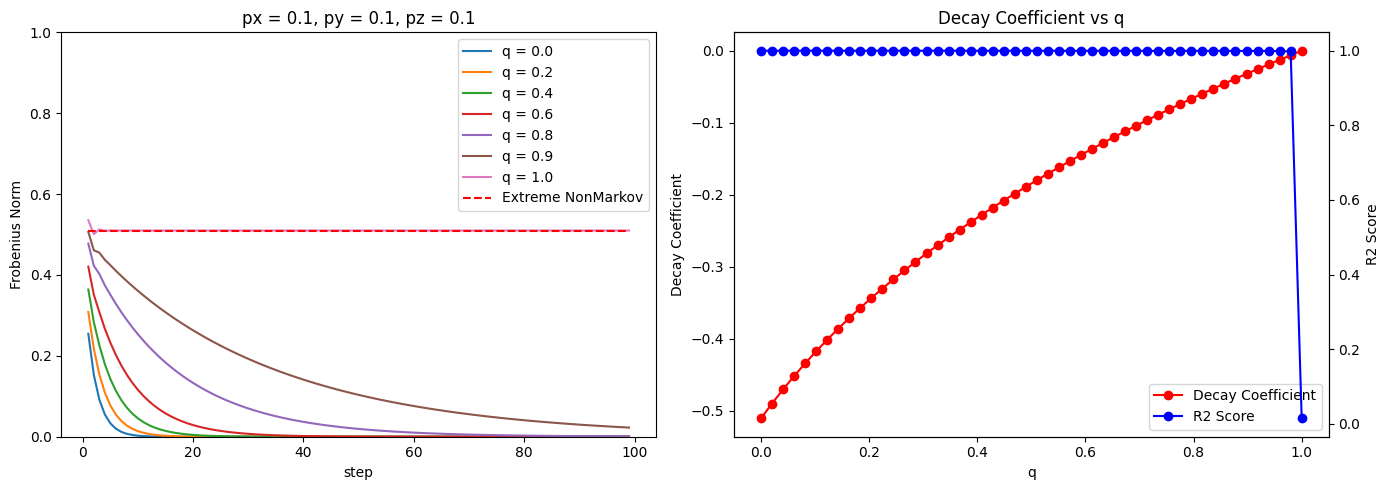

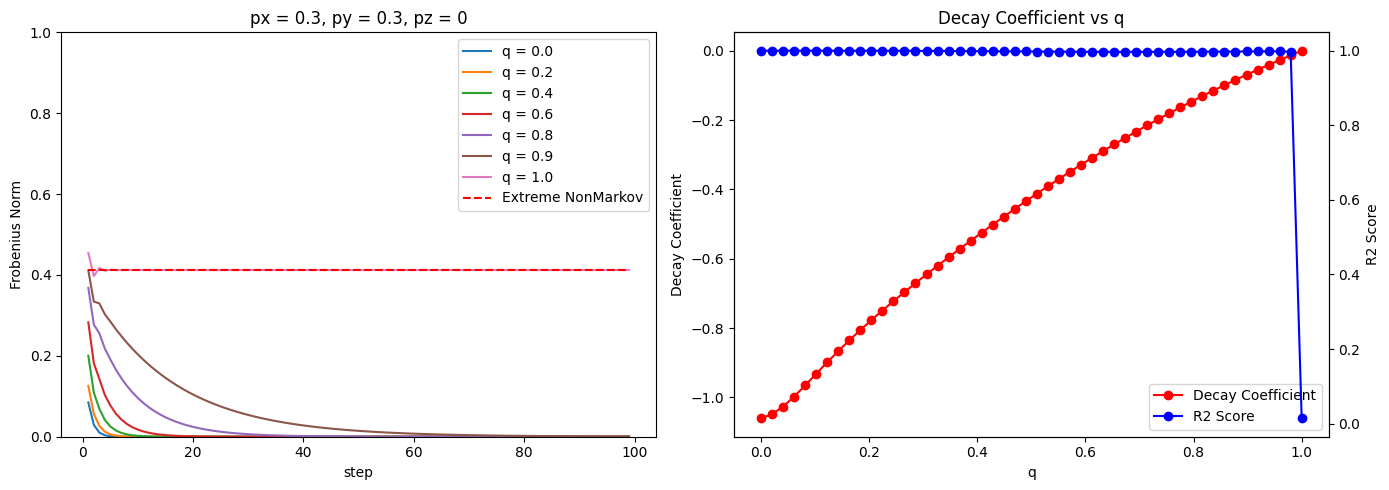

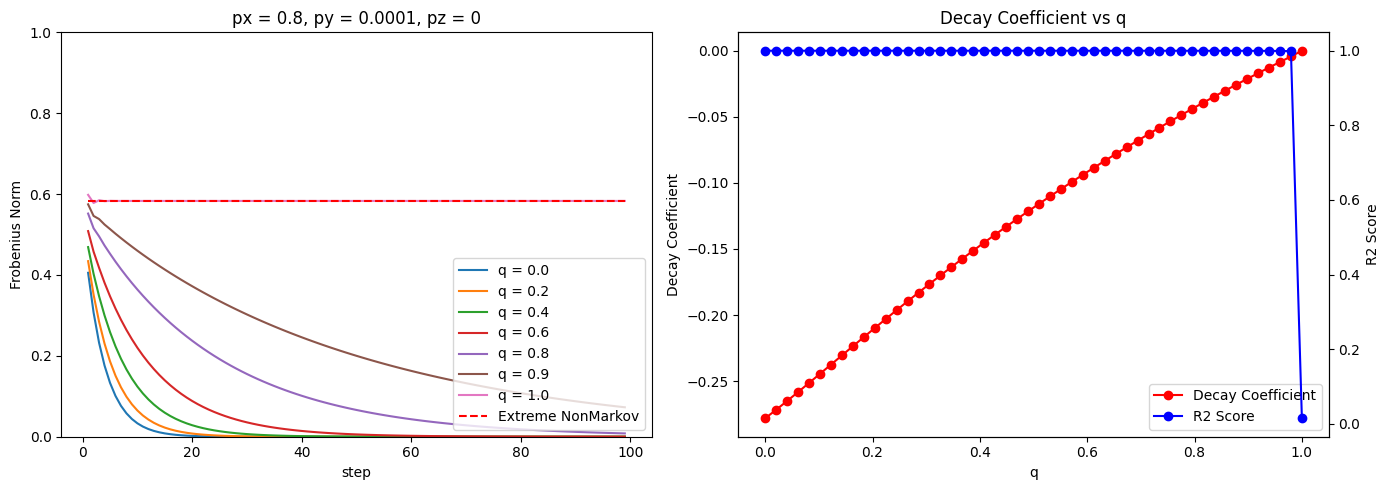

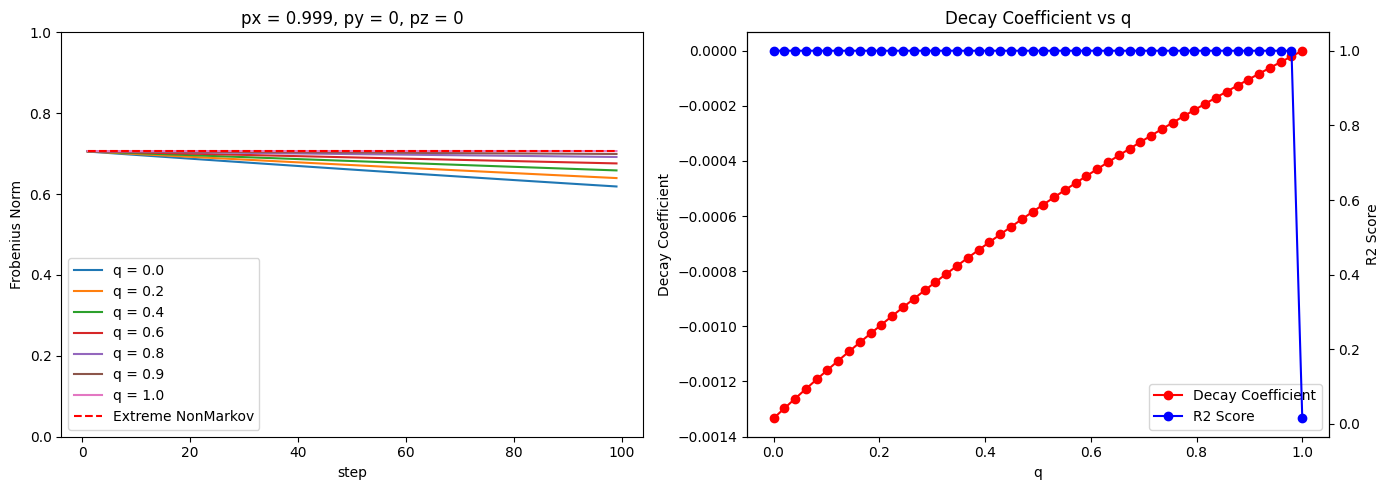

In [200]:
PROB_LIST = [ prob_list(0.1,0.1,0.1), prob_list(0.3,0.3,0), prob_list(0.8,0.0001,0), prob_list(0.999,0,0)]
step_list = np.arange(1,100)

for prob in PROB_LIST:
    calculate_total(prob, step_list)



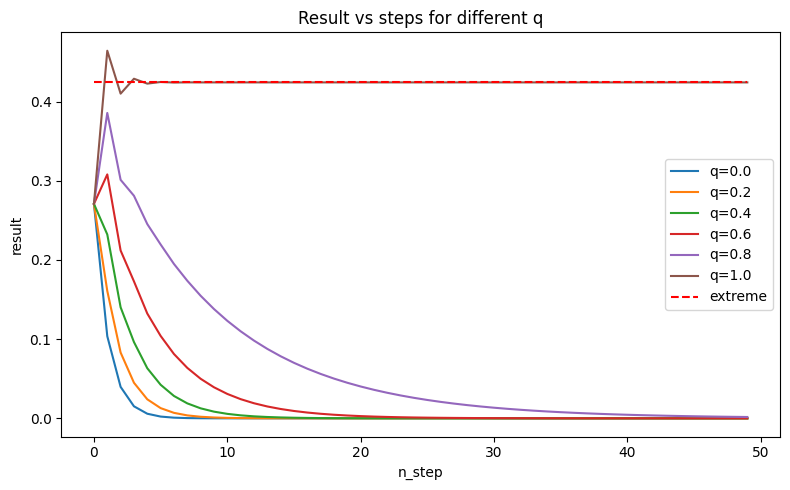

In [163]:
q_list = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
step_list = np.arange(0,50)

px = 0.1
py = 0.1
pz = 0.5
p0 = 1 - (px+py+pz)
PROB = [p0, px, py, pz]

plt.figure(figsize=(8, 5))

for q in q_list:
    frob_list = [calculate_frobnorm(q, PROB, step) for step in step_list]
    plt.plot(step_list, frob_list, label=f'q={q}')

extreme_list = [extreme_case(PROB) for _ in step_list]
plt.plot(step_list, extreme_list, label="extreme", color = 'red', linestyle = '--')

plt.xlabel('n_step')
plt.ylabel('result')
plt.title('Result vs steps for different q')
plt.legend()
plt.tight_layout()
plt.show()

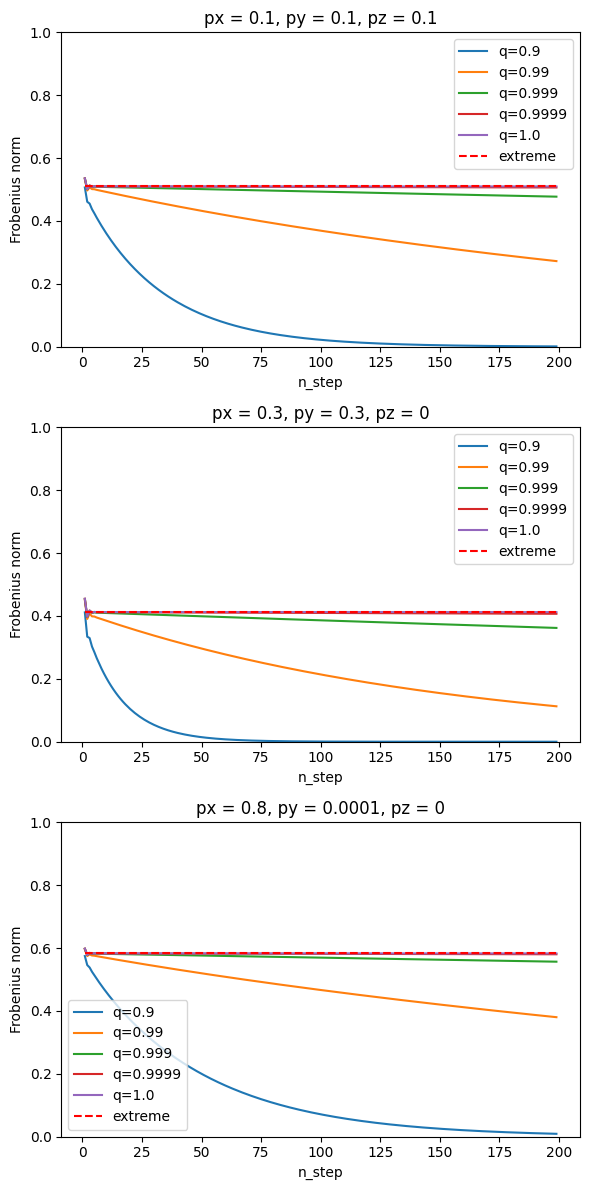

In [174]:
PROB_LIST = [ prob_list(0.1,0.1,0.1), prob_list(0.3,0.3,0), prob_list(0.8,0.0001,0)]
q_list = [ 0.9, 0.99, 0.999, 0.9999,  1.0]

step_list = np.arange(1,200)



fig, axes = plt.subplots(len(PROB_LIST),1,figsize=(6,4 * len(PROB_LIST)))
axes = axes.flatten()

for idx, PROB in enumerate(PROB_LIST):
    for q in q_list:
        frob_list = [calculate_frobnorm(q, PROB, step) for step in step_list]
        axes[idx].plot(step_list, frob_list, label=f'q={q}')

    extreme_list = [extreme_case(PROB) for _ in step_list]
    axes[idx].plot(step_list, extreme_list, label="extreme", color = 'red', linestyle = '--')

    axes[idx].set_title(f'px = {PROB[1]}, py = {PROB[2]}, pz = {PROB[3]}')
    axes[idx].legend()
    axes[idx].set_xlabel('n_step')
    axes[idx].set_ylabel('Frobenius norm')
    axes[idx].set_ylim(0,1)

plt.tight_layout()
plt.show()






## Compare Decay Coefficient vs q

In [165]:
px = 0.2
py = 0.2
pz = 0.1
PROB = prob_list(px,py,pz)

q = 0.4
num_step = 50

step_list = np.arange(1,num_step)



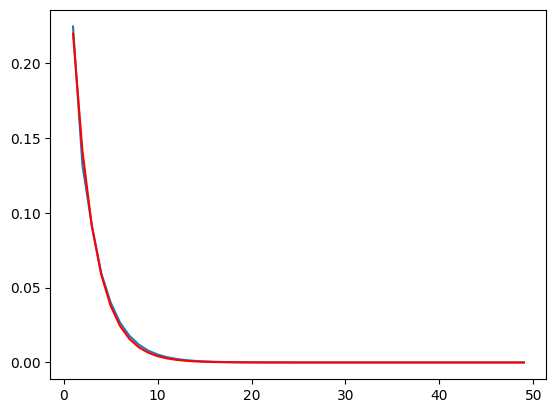

In [168]:


frob_list = [calculate_frobnorm(q, PROB, step) for step in step_list]

popt, pcov = curve_fit(exp_func,step_list,frob_list, p0 = [1,-0.1])

a,b = popt




plt.plot(step_list, frob_list)
plt.plot(step_list, exp_func(step_list,a,b), color = 'red')

In [169]:
print( *popt)

0.340853813403628 -0.43933495116496873


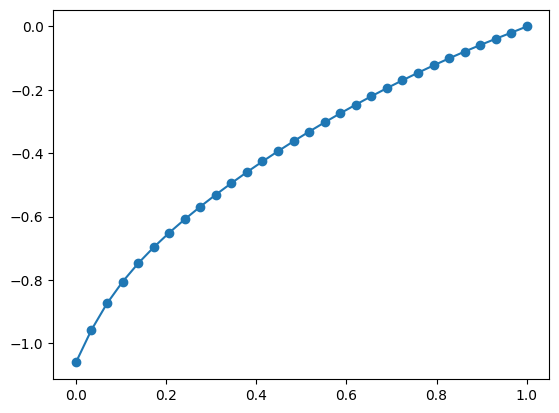

In [173]:
q_list = np.linspace(0,1,30)

decay_coeffs = []

for q in q_list:
    frob_list = [calculate_frobnorm(q, PROB, step) for step in step_list]
    popt, _ = curve_fit(exp_func,step_list,frob_list, p0 = [1,-0.1])
    decay_coeffs.append(popt[1])

plt.plot(q_list, decay_coeffs, marker = 'o')